
Dataset Loaded
Shape: (499, 7)

First 5 rows:


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram



Columns Selected:


,text,sentiment
0,What a great day!!! Looks like dream.,positive
1,"I feel sorry, I miss you here in the sea beach",positive
2,Don't angry me,negative
3,We attend in the class just for listening teac...,negative
4,"Those who want to go, let them go",negative



Cleaned Text Example:


,text,clean_text
0,What a great day!!! Looks like dream.,great day look like dream
1,"I feel sorry, I miss you here in the sea beach",feel sorry miss sea beach
2,Don't angry me,angry
3,We attend in the class just for listening teac...,attend class listening teacher reading slide n...
4,"Those who want to go, let them go",want go let go



TF-IDF Features Created
Feature Matrix Shape: (499, 1210)

Train Test Split Done

Model Training Completed

Prediction Completed

Model Accuracy: 0.59

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.28      0.43        36
     neutral       0.43      0.97      0.59        30
    positive       0.91      0.59      0.71        34

    accuracy                           0.59       100
   macro avg       0.78      0.61      0.58       100
weighted avg       0.80      0.59      0.58       100



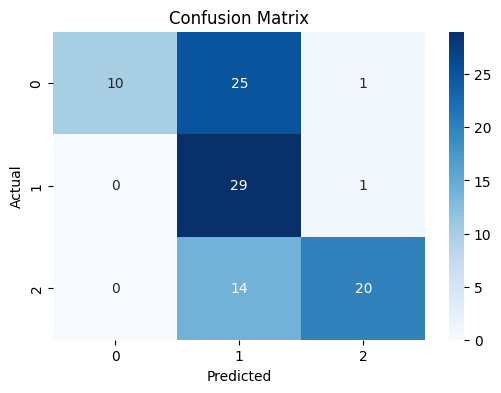

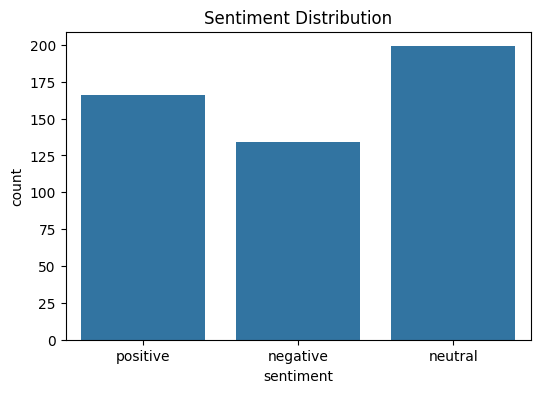


Example Predictions:
Sentence: This product is amazing
Sentiment: positive

Sentence: Worst experience ever
Sentiment: neutral


In [6]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# ==============================
# 2. Download NLTK Data
# ==============================

nltk.download('stopwords')
nltk.download('wordnet')

# ==============================
# 3. Load Dataset
# ==============================

df = pd.read_csv("sentiment_analysis.csv")

print("\nDataset Loaded")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

# ==============================
# 4. Select Required Columns
# ==============================

df = df[['text','sentiment']]
df.dropna(inplace=True)

print("\nColumns Selected:")
display(df.head())

# ==============================
# 5. Text Preprocessing
# ==============================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

print("\nCleaned Text Example:")
display(df[['text','clean_text']].head())

# ==============================
# 6. TF-IDF Feature Extraction
# ==============================

vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['sentiment']

print("\nTF-IDF Features Created")
print("Feature Matrix Shape:", X.shape)

# ==============================
# 7. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain Test Split Done")

# ==============================
# 8. Train Model
# ==============================

model = LogisticRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")

# ==============================
# 9. Predictions
# ==============================

y_pred = model.predict(X_test)

print("\nPrediction Completed")

# ==============================
# 10. Evaluation
# ==============================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==============================
# 11. Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==============================
# 12. Sentiment Distribution
# ==============================

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

# ==============================
# 13. Custom Prediction
# ==============================

def predict_sentiment(sentence):

    sentence = clean_text(sentence)

    vector = vectorizer.transform([sentence])

    prediction = model.predict(vector)

    return prediction[0]


print("\nExample Predictions:")
print("Sentence: This product is amazing")
print("Sentiment:", predict_sentiment("This product is amazing"))

print("\nSentence: Worst experience ever")
print("Sentiment:", predict_sentiment("Worst experience ever"))